In [20]:
# === Colab Starter: Clean Imports + Setup ===

# Install / upgrade libs you need (quiet to keep logs clean)
!pip -q install --upgrade ngboost

# Core
import os, time
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics / time series
from scipy.stats import skew, kurtosis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Scikit-learn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.mixed_precision import set_global_policy

# NGBoost
from ngboost import NGBRegressor
from ngboost.distns import Normal
from ngboost.scores import MLE

# Utilities
import joblib
from itertools import product

In [6]:
# ---- Google Drive ----
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# ---- Reproducibility ----
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

# ---- (Optional) Mixed precision for speed on GPU ----
try:
    set_global_policy('mixed_float16')
except Exception as e:
    print(f"Mixed precision not set: {e}")

# ---- Plotting defaults ----
%matplotlib inline
sns.set(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams["figure.figsize"] = (10, 6)

In [10]:
# ---- Handy env print ----
def print_versions():
    print("TF:", tf.__version__)
    import sklearn, statsmodels, scipy
    print("scikit-learn:", sklearn.__version__)
    print("statsmodels:", statsmodels.__version__)
    print("scipy:", scipy.__version__)
    import ngboost
    print("ngboost:", ngboost.__version__)

print_versions()

TF: 2.19.0
scikit-learn: 1.6.1
statsmodels: 0.14.5
scipy: 1.16.1
ngboost: 0.5.6


In [11]:
df = pd.read_csv("/content/drive/My Drive/CAMEL_ML_internal/camel_train.csv")
df_usgs = pd.read_csv("/content/drive/My Drive/df_usgs.csv")
df_usgs

,Unnamed: 0,Site,Latitude,Longitude,DA,Precip,Elev,IndexFlood
0,0,1018500,45.568333,-67.428333,410.0,1227.494385,140,2995.0
1,1,1049000,44.716667,-69.413889,572.0,1144.720215,56,7310.0
2,2,1064500,43.990833,-71.090556,385.0,1281.516724,149,17950.0
3,3,1081000,43.441744,-71.587575,471.0,1175.859253,173,2530.0
4,4,1096500,42.667589,-71.575068,435.0,1180.636353,74,4090.0
...,...,...,...,...,...,...,...,...
3076,3076,14309500,42.804004,-123.610907,86.9,1517.460938,605,5265.0
3077,3077,14313500,43.322069,-122.195591,170.0,1691.682373,1350,484.0
3078,3078,14316700,43.349842,-122.728942,227.0,1292.377319,620,13100.0
3079,3079,14325000,42.891499,-124.070652,169.0,1565.536133,223,15800.0


In [14]:
# Dummy data
np.random.seed(0)
X = np.random.rand(1000, 5)
y = np.random.rand(1000)

# Normalize
X = StandardScaler().fit_transform(X)
y = StandardScaler().fit_transform(y.reshape(-1, 1)).flatten()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# NGBoost
ngb = NGBRegressor(Dist=Normal, n_estimators=300)
ngb.fit(X_train, y_train)

# Predict distribution
y_dist = ngb.pred_dist(X_test)
mean = y_dist.loc
std = y_dist.scale

# Inverse CI (optional)
lower = mean - 1.96 * std
upper = mean + 1.96 * std

# Print
for i in range(5):
    print(f"Predicted: {mean[i]:.3f} ± {1.96 * std[i]:.3f} → CI: [{lower[i]:.3f}, {upper[i]:.3f}]")

[iter 0] loss=1.4193 val_loss=0.0000 scale=2.0000 norm=2.0006
[iter 100] loss=1.3591 val_loss=0.0000 scale=1.0000 norm=0.9572
[iter 200] loss=1.3149 val_loss=0.0000 scale=2.0000 norm=1.8654
Predicted: -0.258 ± 1.881 → CI: [-2.139, 1.623]
Predicted: -0.167 ± 1.821 → CI: [-1.988, 1.654]
Predicted: -0.090 ± 1.860 → CI: [-1.950, 1.770]
Predicted: -0.062 ± 1.895 → CI: [-1.957, 1.834]
Predicted: -0.181 ± 1.772 → CI: [-1.953, 1.591]


/usr/local/lib/python3.11/dist-packages/ngboost/distns/normal.py:71: RuntimeWarning: overflow encountered in square
  self.var = self.scale**2


Test MSE: 76672959.249212
Test NLL: 9.609895470962845


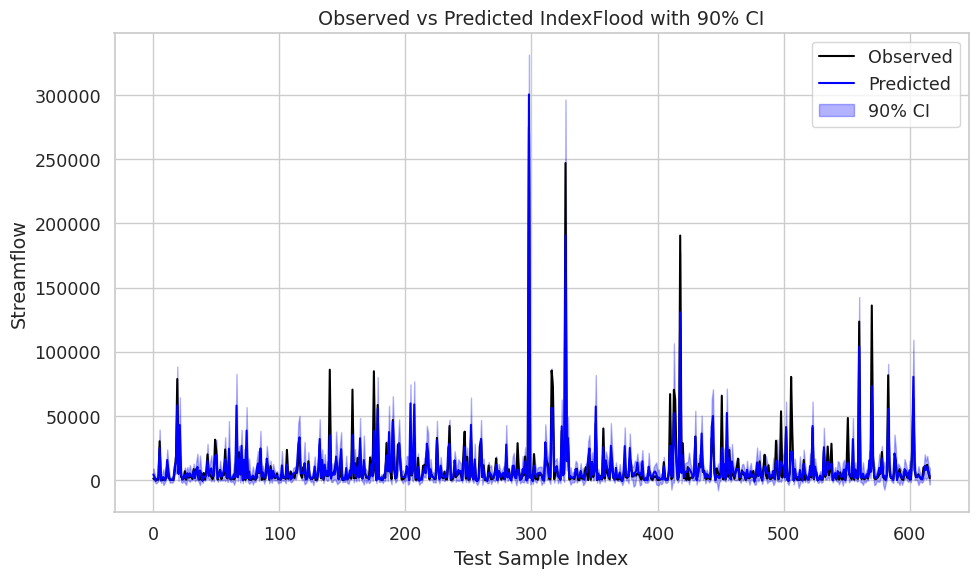

In [15]:
# Application of NGBRegressor in Atmosphere/Hydrology domain
############################################################

# Load your data
df_usgs = pd.read_csv("/content/drive/My Drive/df_usgs.csv")

# Define features and target
features = ['Latitude', 'Longitude', 'DA', 'Precip', 'Elev']
target = 'IndexFlood'

# Standardize 'DA', 'Precip', 'Elev'
to_standardize = ['DA', 'Precip', 'Elev']
scaler = StandardScaler()
df_usgs[to_standardize] = scaler.fit_transform(df_usgs[to_standardize])

# Split data
X = df_usgs[features]
y = df_usgs[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train NGBoost
ngb = NGBRegressor(verbose=False)
ngb.fit(X_train, y_train)

# Predict
y_preds = ngb.predict(X_test)
y_dists = ngb.pred_dist(X_test)

# Evaluation
test_MSE = mean_squared_error(y_test, y_preds)
test_NLL = -y_dists.logpdf(y_test).mean()
print("Test MSE:", test_MSE)
print("Test NLL:", test_NLL)

# Plot: Prediction vs Observed with 90% CI
y_lower = y_dists.dist.ppf(0.05)
y_upper = y_dists.dist.ppf(0.95)

plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Observed', color='black')
plt.plot(y_preds, label='Predicted', color='blue')
plt.fill_between(range(len(y_preds)), y_lower, y_upper, color='blue', alpha=0.3, label='90% CI')
plt.title("Observed vs Predicted IndexFlood with 90% CI")
plt.xlabel("Test Sample Index")
plt.ylabel("Streamflow")
plt.legend()
plt.tight_layout()
plt.show()

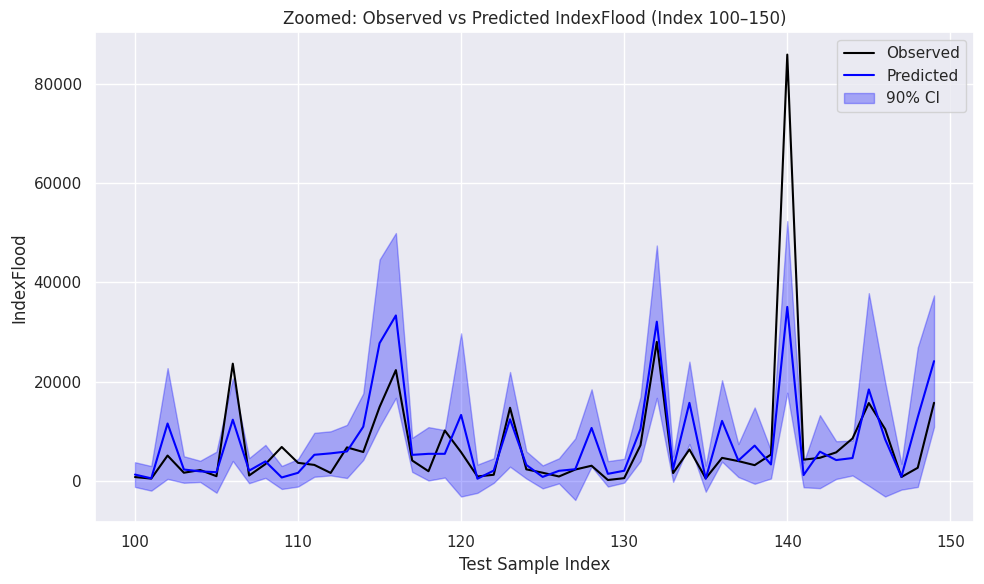

In [ ]:
# Zoom-in range
start_idx, end_idx = 100, 150

# Slice predictions and true values
obs_zoom = y_test.values[start_idx:end_idx]
pred_zoom = y_preds[start_idx:end_idx]
lower_zoom = y_lower[start_idx:end_idx]
upper_zoom = y_upper[start_idx:end_idx]

# Plot zoomed section
plt.figure(figsize=(10, 6))
plt.plot(range(start_idx, end_idx), obs_zoom, label='Observed', color='black')
plt.plot(range(start_idx, end_idx), pred_zoom, label='Predicted', color='blue')
plt.fill_between(range(start_idx, end_idx), lower_zoom, upper_zoom, color='blue', alpha=0.3, label='90% CI')
plt.title(f"Zoomed: Observed vs Predicted IndexFlood (Index {start_idx}–{end_idx})")
plt.xlabel("Test Sample Index")
plt.ylabel("IndexFlood")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# Number of realizations
n_samples = 100

# Draw samples from predictive distribution
samples = y_dists.sample(n_samples)  # shape: (100, n_test_samples)

# Percentile-based summary
quantiles = {
    "p05": np.percentile(samples, 5, axis=0),
    "p10": np.percentile(samples, 10, axis=0),
    "p25": np.percentile(samples, 25, axis=0),
    "p50": np.percentile(samples, 50, axis=0),  # Median
    "p75": np.percentile(samples, 75, axis=0),
    "p90": np.percentile(samples, 90, axis=0),
    "p95": np.percentile(samples, 95, axis=0)
}

median_preds = quantiles["p50"]
# ci_90_lower = quantiles["p05"]
# ci_90_upper = quantiles["p95"]

median_preds

array([ 5.07982142e+03,  2.17839799e+03, -4.74032416e+02,  7.70277836e+02,
        1.97837779e+03,  2.38437537e+04, -5.13385847e+02,  1.73441246e+03,
        1.99884508e+03, -3.29958489e+02,  2.61240420e+03,  1.59560262e+04,
        6.63608753e+03,  4.50461324e+02,  3.17770477e+02,  2.68800558e+02,
        1.71886768e+03,  1.11776434e+04,  1.36706627e+04,  5.96964331e+04,
        5.41365540e+03,  4.31590339e+04,  3.88043832e+03,  6.47396256e+02,
        2.20804291e+03,  3.27368920e+03,  1.98328062e+03,  5.67621391e+03,
        3.12741454e+03,  5.23796319e+03,  3.40694012e+03,  2.61215010e+03,
        7.24401611e+03,  1.43748516e+03,  6.77706024e+03,  1.00348619e+04,
        8.24795690e+02,  8.42398853e+03,  5.29158876e+03, -5.24013532e+02,
        3.07865641e+03,  2.41400042e+03,  3.73505071e+03,  1.33592767e+04,
        3.18891048e+03,  6.46228741e+03,  9.49444799e+03,  3.40537440e+03,
        3.99158609e+03,  1.80782671e+04,  1.98090432e+04,  1.25117245e+03,
        3.76924933e+03,  

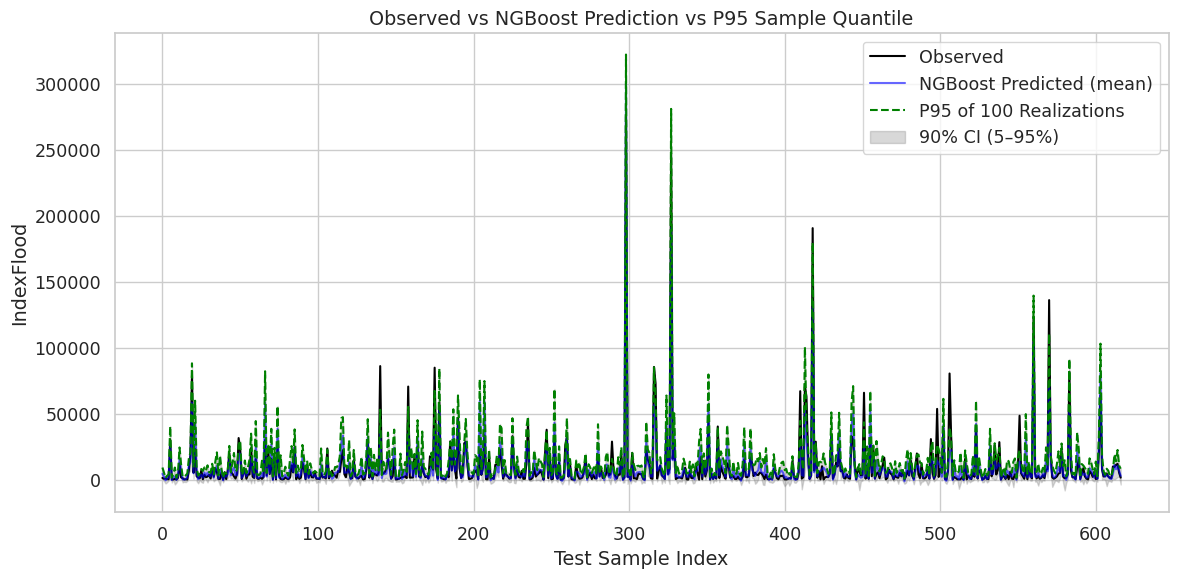

In [17]:
# Control param: choose which quantile to plot
quantile_key = "p95"  # Change to "p50", "p75", etc. as needed

# Full range plot
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Observed', color='black')
plt.plot(y_preds, label='NGBoost Predicted (mean)', color='blue', alpha=0.6)
plt.plot(quantiles[quantile_key], label=f'{quantile_key.upper()} of 100 Realizations', color='green', linestyle='--')
plt.fill_between(range(len(y_test)), quantiles["p05"], quantiles["p95"], color='gray', alpha=0.3, label='90% CI (5–95%)')

plt.title(f"Observed vs NGBoost Prediction vs {quantile_key.upper()} Sample Quantile")
plt.xlabel("Test Sample Index")
plt.ylabel("IndexFlood")
plt.legend()
plt.tight_layout()
plt.show()

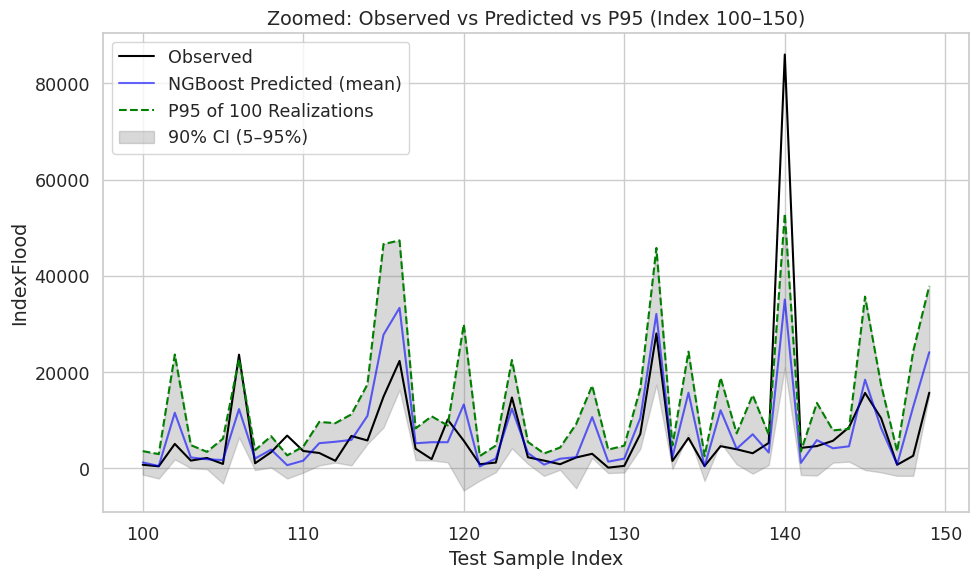

In [18]:
# Zoom-in range
start_idx, end_idx = 100, 150
indices = range(start_idx, end_idx)

# Slice data
obs_zoom = y_test.values[start_idx:end_idx]
pred_zoom = y_preds[start_idx:end_idx]
quantile_zoom = quantiles[quantile_key][start_idx:end_idx]
lower_zoom = quantiles["p05"][start_idx:end_idx]
upper_zoom = quantiles["p95"][start_idx:end_idx]

# Zoomed plot
plt.figure(figsize=(10, 6))
plt.plot(indices, obs_zoom, label='Observed', color='black')
plt.plot(indices, pred_zoom, label='NGBoost Predicted (mean)', color='blue', alpha=0.6)
plt.plot(indices, quantile_zoom, label=f'{quantile_key.upper()} of 100 Realizations', color='green', linestyle='--')
plt.fill_between(indices, lower_zoom, upper_zoom, color='gray', alpha=0.3, label='90% CI (5–95%)')

plt.title(f"Zoomed: Observed vs Predicted vs {quantile_key.upper()} (Index {start_idx}–{end_idx})")
plt.xlabel("Test Sample Index")
plt.ylabel("IndexFlood")
plt.legend()
plt.tight_layout()
plt.show()

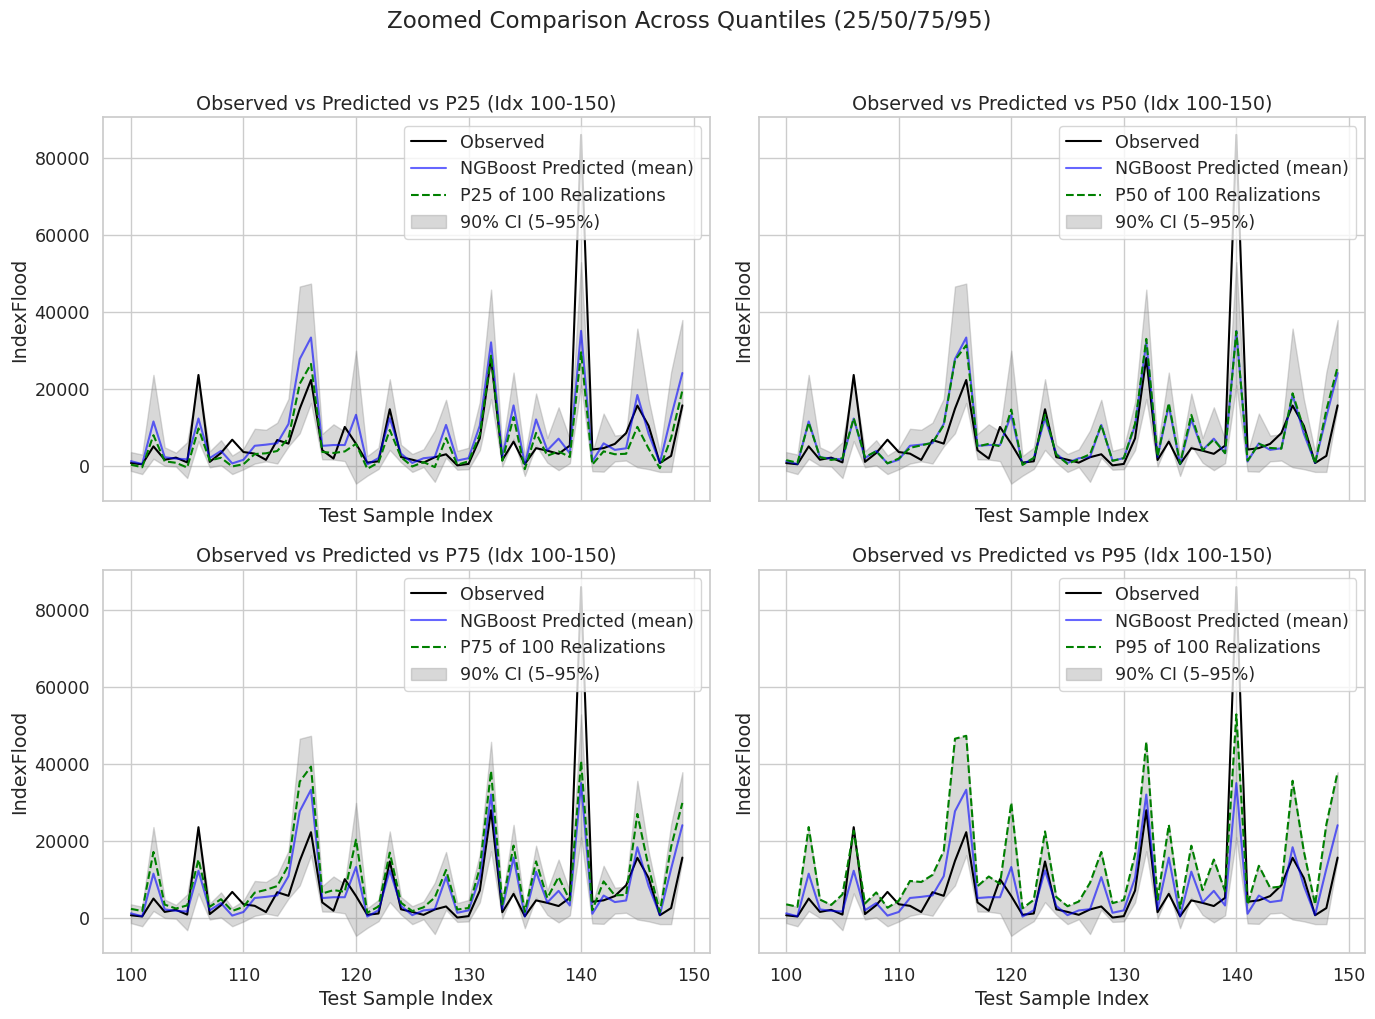

In [19]:
start_idx, end_idx = 100, 150
indices = np.arange(start_idx, end_idx)

# Common zoom slices
obs_zoom   = y_test.values[start_idx:end_idx]
pred_zoom  = y_preds[start_idx:end_idx]
lower_zoom = quantiles["p05"][start_idx:end_idx]
upper_zoom = quantiles["p95"][start_idx:end_idx]

quantile_keys = ["p25", "p50", "p75", "p95"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

for ax, qk in zip(axes.ravel(), quantile_keys):
    q_zoom = quantiles[qk][start_idx:end_idx]
    ax.plot(indices, obs_zoom, label='Observed', color='black')
    ax.plot(indices, pred_zoom, label='NGBoost Predicted (mean)', color='blue', alpha=0.6)
    ax.plot(indices, q_zoom, label=f'{qk.upper()} of 100 Realizations', color='green', linestyle='--')
    ax.fill_between(indices, lower_zoom, upper_zoom, color='gray', alpha=0.3, label='90% CI (5–95%)')
    ax.set_title(f"Observed vs Predicted vs {qk.upper()} (Idx {start_idx}-{end_idx})")
    ax.set_xlabel("Test Sample Index")
    ax.set_ylabel("IndexFlood")
    ax.legend(loc='upper right')

fig.suptitle("Zoomed Comparison Across Quantiles (25/50/75/95)", y=1.02)
plt.tight_layout()
plt.show()

The plots show that the NGBoost mean and p50 follow typical behavior but can miss sharp peaks, p25 underestimates and rarely covers peaks, while p75—and especially p95—capture most peaks at the cost of overprediction between events. Choose the quantile to match risk: p50 for routine forecasting, p75 for safety-leaning use, and p95 for conservative, peak-critical decisions; avoid p25 when peak coverage matters.

In [ ]:
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

# --- CONFIG ---
quantile_keys = ['p05', 'p10', 'p25', 'p50', 'p75', 'p90', 'p95']
zoom_size = 50  # Number of samples for zoomed-in subsets

# --- FUNCTION: Identify outliers using IQR ---
def get_outlier_indices(y):
    q1, q3 = np.percentile(y, [25, 75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return np.where((y < lower) | (y > upper))[0]

# --- FUNCTION: Safe R² computation ---
def safe_r2(y_true, y_pred, idx):
    return round(r2_score(y_true[idx], y_pred[idx]), 4) if len(idx) > 0 else np.nan

# === 1. TRAIN FULL ===
train_dists = ngb.pred_dist(X_train)
train_samples = train_dists.sample(100)
train_quantiles = {
    q: np.percentile(train_samples, int(q[1:]), axis=0)
    for q in quantile_keys
}
y_train_arr = y_train if isinstance(y_train, np.ndarray) else y_train.values
train_out_idx = get_outlier_indices(y_train_arr)

# === 2. TEST FULL ===
test_samples = y_dists.sample(100)
test_quantiles = {
    q: np.percentile(test_samples, int(q[1:]), axis=0)
    for q in quantile_keys
}
y_test_arr = y_test if isinstance(y_test, np.ndarray) else y_test.values
test_out_idx = get_outlier_indices(y_test_arr)

# === 3. ZOOMED-IN TRAIN SUBSET ===
X_zoom_train = X_train[:zoom_size]
y_zoom_train = y_train_arr[:zoom_size]
zoom_train_dists = ngb.pred_dist(X_zoom_train)
zoom_train_samples = zoom_train_dists.sample(100)
zoom_train_quantiles = {
    q: np.percentile(zoom_train_samples, int(q[1:]), axis=0)
    for q in quantile_keys
}
zoom_train_out_idx = get_outlier_indices(y_zoom_train)

# === 4. ZOOMED-IN TEST SUBSET ===
X_zoom_test = X_test[:zoom_size]
y_zoom_test = y_test_arr[:zoom_size]
zoom_test_dists = ngb.pred_dist(X_zoom_test)
zoom_test_samples = zoom_test_dists.sample(100)
zoom_test_quantiles = {
    q: np.percentile(zoom_test_samples, int(q[1:]), axis=0)
    for q in quantile_keys
}
zoom_test_out_idx = get_outlier_indices(y_zoom_test)

# === Compile All Results ===
results = []
for q in quantile_keys:
    r2_train = safe_r2(y_train_arr, train_quantiles[q], train_out_idx)
    r2_test = safe_r2(y_test_arr, test_quantiles[q], test_out_idx)
    r2_zoom_train = safe_r2(y_zoom_train, zoom_train_quantiles[q], zoom_train_out_idx)
    r2_zoom_test = safe_r2(y_zoom_test, zoom_test_quantiles[q], zoom_test_out_idx)

    results.append({
        "Quantile": q.upper(),
        "R2_Out_Train": r2_train,
        "R2_Out_Test": r2_test,
        "R2_Out_ZoomTrain": r2_zoom_train,
        "R2_Out_ZoomTest": r2_zoom_test
    })

# === Display Final Table ===
r2_outlier_df = pd.DataFrame(results)
print(r2_outlier_df)

  Quantile  R2_Out_Train  R2_Out_Test  R2_Out_ZoomTrain  R2_Out_ZoomTest
0      P05       -0.6014       0.2634          -13.2156          -2.6564
1      P10       -0.6014       0.3887          -13.2155          -2.6563
2      P25       -0.6014       0.6039          -13.2153          -2.6563
3      P50       -0.6014       0.7504          -13.2151          -2.6562
4      P75       -0.6014       0.7883          -13.2149          -2.6562
5      P90       -0.6014       0.7631          -13.2146          -2.6561
6      P95       -0.6014       0.7219          -13.2145          -2.6561


In [ ]:
# Perfomance for outliers
# For the full range and a particular zoomed-in dataset, I need the outliers each datasets and compare the predicted value for any given
# quantile and calculate the R2. The goal is to see the performance in the outliers.
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

# --- CONFIG ---
start_idx, end_idx = 100, 150
quantile_keys = ['p05', 'p10', 'p25', 'p50', 'p75', 'p90', 'p95']

# --- FUNCTION: Identify outliers by IQR ---
def get_outlier_indices(y):
    q1, q3 = np.percentile(y, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return np.where((y < lower_bound) | (y > upper_bound))[0]

# --- Outliers ---
y_test_full = y_test.values
y_test_zoom = y_test[start_idx:end_idx].values

outlier_idx_full = get_outlier_indices(y_test_full)
outlier_idx_zoom = get_outlier_indices(y_test_zoom)

# --- Compute R² for outliers only ---
r2_outlier_results = []

for q in quantile_keys:
    pred_full = quantiles[q]
    pred_zoom = pred_full[start_idx:end_idx]

    if len(outlier_idx_full) > 0:
        r2_full = r2_score(y_test_full[outlier_idx_full], pred_full[outlier_idx_full])
    else:
        r2_full = np.nan

    if len(outlier_idx_zoom) > 0:
        r2_zoom = r2_score(y_test_zoom[outlier_idx_zoom], pred_zoom[outlier_idx_zoom])
    else:
        r2_zoom = np.nan

    r2_outlier_results.append({
        "Quantile": q.upper(),
        "R2_Outlier_Full": round(r2_full, 4),
        "R2_Outlier_Zoomed": round(r2_zoom, 4)
    })

# --- Final table ---
r2_outlier_df = pd.DataFrame(r2_outlier_results)
print(r2_outlier_df)

  Quantile  R2_Outlier_Full  R2_Outlier_Zoomed
0      P05           0.2774            -0.2953
1      P10           0.4209            -0.1458
2      P25           0.6177             0.0320
3      P50           0.7442             0.1863
4      P75           0.7984             0.1922
5      P90           0.7708            -0.0540
6      P95           0.7341            -0.1270


Test MSE: 0.3250195875764306
Test NLL: 0.7016210299502821


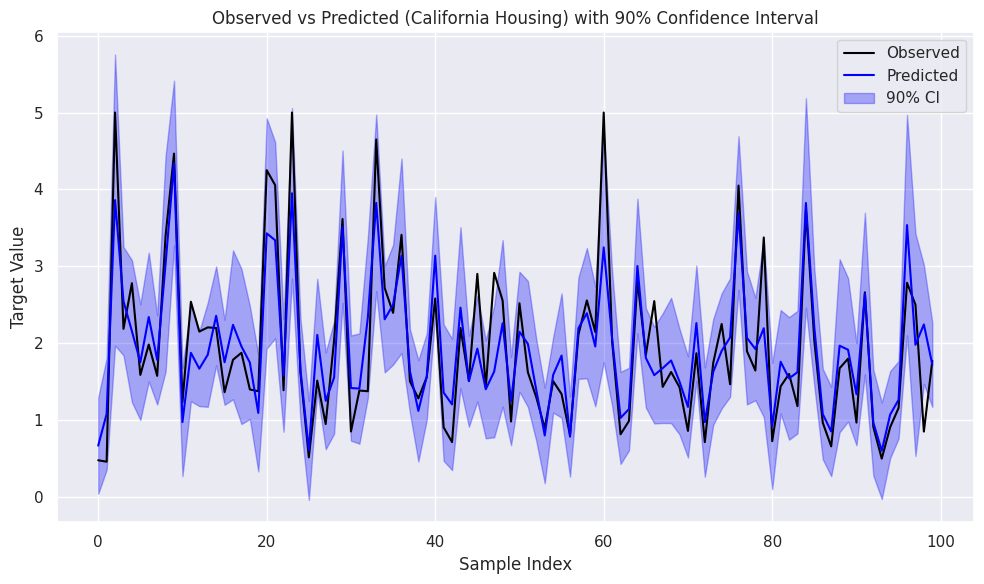

In [ ]:
# Application of NGBRegressor in Real-state
###########################################

# Load California housing dataset
housing = fetch_california_housing()
X, Y = housing.data, housing.target

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Train NGBoost
ngb = NGBRegressor(verbose=False)
ngb.fit(X_train, Y_train)

# Predict
Y_preds = ngb.predict(X_test)
Y_dists = ngb.pred_dist(X_test)

# Evaluation
test_MSE = mean_squared_error(Y_preds, Y_test)
test_NLL = -Y_dists.logpdf(Y_test).mean()
print("Test MSE:", test_MSE)
print("Test NLL:", test_NLL)

# Prediction Uncertainty Bands (90% CI)
Y_lower = Y_dists.dist.ppf(0.05)
Y_upper = Y_dists.dist.ppf(0.95)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(Y_test[:100], label='Observed', color='black')
plt.plot(Y_preds[:100], label='Predicted', color='blue')
plt.fill_between(range(100), Y_lower[:100], Y_upper[:100], color='blue', alpha=0.3, label='90% CI')
plt.title("Observed vs Predicted (California Housing) with 90% Confidence Interval")
plt.xlabel("Sample Index")
plt.ylabel("Target Value")
plt.legend()
plt.tight_layout()
plt.show()

NGBoost tracks the signal well: the mean prediction follows observations and the 90% interval widens near volatile peaks and tightens in stable regions. Most points fall inside the band, with only a few sharp spikes escaping it, suggesting decent calibration. Use the median for central forecasts and rely on upper quantiles when peak risk matters.

In [21]:
!git clone https://github.com/Almehedi06/ML-projects.git
%cd ML-projects/notebooks

Cloning into 'ML-projects'...
remote: Enumerating objects: 116, done.
remote: Counting objects: 100% (116/116), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 116 (delta 13), reused 21 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (116/116), 10.00 MiB | 11.99 MiB/s, done.
Resolving deltas: 100% (13/13), done.
/content/ML-projects/notebooks


In [22]:
# Replace with your Colab notebook filename
!cp "/content/drive/My Drive/.ipynb" "/content/ML-projects/notebooks/"

cp: cannot stat '/content/drive/My Drive/.ipynb': No such file or directory


In [23]:
!ls /content
!ls "/content/drive/My Drive/Colab Notebooks"

drive  ML-projects  sample_data
 Budget.ipynb
'CAMEL ML1_FE_WS.ipynb'
'channel roughness prediction.ipynb'
 class.ipynb
 CN-Copy1.ipynb
'Copy of 04.14-Visualization-With-Seaborn.ipynb'
'Copy of CAMEL ML1_RF.ipynb'
'Copy of Detecting Changes in Sentinel-1 Imagery (Part 1) (PHL)'
'Copy of EWRI_Sed_Wiz_Visualization.ipynb'
'Copy of LSTM.ipynb'
'Copy of P1_DC_DT.ipynb'
'Copy of PP65_time-series-rnn-full-predict.ipynb'
'Copy of results.ipynb'
'Copy of SDE_GD2_AGU24.ipynb'
'Culvert1(draft).ipynb'
'Culvert(draft).ipynb'
 Culvert_elevation_slope.ipynb
 Culvert_Extrapolate.ipynb
'Culvert_hydraulicQ(1).ipynb'
'Culvert_hydraulicQ(draft1).ipynb'
'Culvert_hydraulicQ(draft).ipynb'
 Culvert_hydraulicQ.ipynb
 Culvertsetjoin.ipynb
'Detecting Changes in Sentinel-1 Imagery (Part 1) (PHL)'
'Detecting Changes in Sentinel-1 Imagery (Part 2) (Dhaka-Flood)'
'Detecting Changes in Sentinel-1 Imagery (Part 2) (PHL-Flood)'
'Detecting Changes in Sentinel-1 Imagery (Part 2) (PHL-noFlood)'
'Detecting Changes in Sent